# KG-Y — análisis de una corrida fusionada

Esta notebook analiza el archivo producido por `merge_rank_outputs_and_cleanup.py`:

```text
<RUN_DIR>/<nombre_de_RUN_DIR>.h5
```

Secciones:

1. estructura y metadatos del HDF5;
2. diagnósticos globales y por multipolo;
3. perfiles radiales de un modo seleccionado;
4. reconstrucciones guardadas en los planos $xy$ y $xz$.

Para no consumir memoria innecesaria, los campos se leen por cortes: un modo y unos tiempos para perfiles, o un solo snapshot para cada plano.

In [ ]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

# ============================================================
# Configuración
# ============================================================
RUN_DIR = Path("SL_all_p001")

# Por defecto se usa: RUN_DIR / f"{RUN_DIR.name}.h5"
# Si deseas otro nombre, reemplaza esta línea.
H5_PATH = RUN_DIR / f"{RUN_DIR.name}.h5"

# Selecciones de las celdas de análisis.
SELECTED_MODE = None         # None -> primer modo disponible; ejemplo: (20, 5)
FIELD_TO_PLOT = "phi"        # "phi" o "pi"
PART_TO_PLOT = "abs"         # "abs", "real" o "imag"
R_DISPLAY_MAX = None         # None -> todo el dominio radial
PLANE_TIME_REQUEST = 10    # None -> último snapshot de planos

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def resolve_h5_path(run_dir, requested):
    requested = Path(requested)
    if requested.is_file():
        return requested

    expected = run_dir / f"{run_dir.name}.h5"
    if expected.is_file():
        return expected

    candidates = sorted(p for p in run_dir.glob("*.h5")
                        if not p.name.startswith("output_rank_"))
    if len(candidates) == 1:
        return candidates[0]

    raise FileNotFoundError(
        f"No encontré un archivo fusionado en {run_dir}. "
        "Ejecuta primero el merge o fija H5_PATH explícitamente."
    )


H5_PATH = resolve_h5_path(RUN_DIR, H5_PATH)
print(f"Archivo: {H5_PATH}")

Archivo: SL_all_p005/SL_all_p005.h5


In [110]:
def print_h5_tree(group, prefix=""):
    for name, obj in group.items():
        path = f"{prefix}/{name}" if prefix else f"/{name}"
        if isinstance(obj, h5py.Group):
            print(f"{path}/")
            print_h5_tree(obj, path)
        else:
            print(f"{path:48s} shape={str(obj.shape):16s} dtype={obj.dtype}")


with h5py.File(H5_PATH, "r") as h5:
    print_h5_tree(h5)

    r = h5["grid/r"][:]
    nmode = h5["modes/nmode"][:]
    ell = h5["modes/ell"][:]
    mm = h5["modes/mm"][:]
    diag_t = h5["diagnostics/t"][:]
    field_t = h5["fields/t"][:]

print("\nResumen")
print(f"  Nr                : {r.size}")
print(f"  r                 : [{r[0]:.8g}, {r[-1]:.8g}]")
print(f"  modos             : {nmode.size}")
print(f"  ell               : [{ell.min()}, {ell.max()}]")
print(f"  snapshots 0D      : {diag_t.size}, t_final = {diag_t[-1]:.8g}")
print(f"  snapshots 1D      : {field_t.size}, t_final = {field_t[-1]:.8g}")
with h5py.File(H5_PATH, "r") as h5:
    print(f"  planos disponibles: {'planes' in h5}")

/diagnostics/
/diagnostics/F                                   shape=(5001, 3721)     dtype=float64
/diagnostics/Finf                                shape=(5001, 3721)     dtype=float64
/diagnostics/N                                   shape=(5001, 3721)     dtype=float64
/diagnostics/t                                   shape=(5001,)          dtype=float64
/fields/
/fields/phi_im                                   shape=(11, 3721, 2209) dtype=float64
/fields/phi_re                                   shape=(11, 3721, 2209) dtype=float64
/fields/pi_im                                    shape=(11, 3721, 2209) dtype=float64
/fields/pi_re                                    shape=(11, 3721, 2209) dtype=float64
/fields/t                                        shape=(11,)            dtype=float64
/grid/
/grid/r                                          shape=(2209,)          dtype=float64
/modes/
/modes/ell                                       shape=(3721,)          dtype=int32
/modes/mm         

## Funciones auxiliares

La salida fusionada usa el layout que `h5py` observa para la escritura Fortran:

```text
N, F               : (time, mode)
phi_re, phi_im, ...: (time, mode, radial)
planos             : (time, angular, radial)
```

In [111]:
def closest_time_index(t, requested=None):
    if requested is None:
        return len(t) - 1
    return int(np.argmin(np.abs(t - requested)))


def mode_index_from_lm(ell_values, m_values, ell_target, m_target):
    indices = np.flatnonzero((ell_values == ell_target) & (m_values == m_target))
    if indices.size == 0:
        raise KeyError(f"No existe el modo (ell, m)=({ell_target}, {m_target}).")
    return int(indices[0])


def selected_mode_index(ell_values, m_values, selection=None):
    return 0 if selection is None else mode_index_from_lm(ell_values, m_values, *selection)


def radial_slice(r, rmax=None):
    if rmax is None:
        return slice(None)
    return slice(0, max(1, np.searchsorted(r, rmax, side="right")))


def complex_modal_field(h5, field, it, imode, rs=slice(None)):
    re = h5[f"fields/{field}_re"][it, imode, rs]
    im = h5[f"fields/{field}_im"][it, imode, rs]
    return re + 1j * im


def component(z, part):
    if part == "abs":
        return np.abs(z)
    if part == "real":
        return z.real
    if part == "imag":
        return z.imag
    raise ValueError("PART_TO_PLOT debe ser 'abs', 'real' o 'imag'.")


def component_label(symbol, part):
    return {
        "abs": rf"$|{symbol}|$",
        "real": rf"$\Re({symbol})$",
        "imag": rf"$\Im({symbol})$",
    }[part]


def summed_modal_series(dataset, mode_block=2048):
    """Suma un dataset (time, mode) sin cargarlo completo."""
    result = np.zeros(dataset.shape[0], dtype=np.float64)
    for j0 in range(0, dataset.shape[1], mode_block):
        j1 = min(j0 + mode_block, dataset.shape[1])
        result += dataset[:, j0:j1].sum(axis=1)
    return result


def sum_by_ell(values, ell_values):
    ell_unique = np.unique(ell_values)
    result = np.empty(ell_unique.size)
    for i, ell_i in enumerate(ell_unique):
        result[i] = values[ell_values == ell_i].sum()
    return ell_unique, result


def orient_angular_radial(array, nangle, nr):
    """Devuelve layout (angular, radial)."""
    if array.shape == (nangle, nr):
        return array
    if array.shape == (nr, nangle):
        return array.T
    raise ValueError(f"Shape de plano no reconocido: {array.shape}.")


def color_norm(values, part):
    values = np.asarray(values)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return None

    if part == "abs":
        positive = finite[finite > 0.0]
        if positive.size == 0:
            return None
        return LogNorm(
            vmin=max(np.percentile(positive, 1.0), np.finfo(float).tiny),
            vmax=np.percentile(positive, 99.8),
        )

    vmax = np.percentile(np.abs(finite), 99.8)
    if vmax == 0.0:
        return None
    return SymLogNorm(
        linthresh=max(vmax * 1.0e-4, np.finfo(float).tiny),
        vmin=-vmax,
        vmax=vmax,
    )


def plane_complex_xy(h5, field, it):
    group = h5["planes/xy"]
    re_name, im_name = f"{field}_re", f"{field}_im"
    if re_name not in group or im_name not in group:
        raise KeyError(f"Faltan {re_name} y/o {im_name} en /planes/xy.")
    return group[re_name][it, ...] + 1j * group[im_name][it, ...]


def plane_complex_xz(h5, field, it, side):
    group = h5["planes/xz"]
    re_name, im_name = f"{field}_re_{side}", f"{field}_im_{side}"
    if re_name not in group or im_name not in group:
        raise KeyError(f"Faltan {re_name} y/o {im_name} en /planes/xz.")
    return group[re_name][it, ...] + 1j * group[im_name][it, ...]

In [112]:
# ============================================================
# Diagnóstico de flujo exterior y balance de carga
# ============================================================

FINF_DATASET = "Finf"

# Convención esperada:
#   F    > 0  : carga que entra al horizonte.
#   Finf > 0  : carga que sale por r = rmax.
#
# Cambia solo este signo si tu definición de Finf usa la
# orientación opuesta.
FINF_SIGN = +1.0


def get_finf_dataset(h5):
    path = f"diagnostics/{FINF_DATASET}"

    if path not in h5:
        available = list(h5["diagnostics"].keys())
        raise KeyError(
            f"No existe /{path}. "
            f"Datasets disponibles en /diagnostics: {available}"
        )

    return h5[path]


def cumulative_trapezoid_1d(t, y):
    """
    Integral acumulada de y(t), con regla del trapecio.
    Devuelve un arreglo de la misma longitud que t.
    """
    t = np.asarray(t)
    y = np.asarray(y)

    result = np.zeros_like(y, dtype=np.float64)

    if t.size < 2:
        return result

    dt = np.diff(t)
    result[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * dt)

    return result


def final_time_integral_per_mode(dataset, t, mode_block=2048):
    """
    Calcula integral temporal final para cada modo sin cargar
    todo el dataset (tiempo, modos) simultáneamente.
    """
    nt, nmodes = dataset.shape
    result = np.empty(nmodes, dtype=np.float64)

    for j0 in range(0, nmodes, mode_block):
        j1 = min(j0 + mode_block, nmodes)

        values = dataset[:, j0:j1]
        result[j0:j1] = np.trapz(values, x=t, axis=0)

    return result


def shared_charge_norm(*arrays):
    """
    Norma común para comparar carga inicial y final.
    Usa escala logarítmica cuando las cargas son positivas.
    """
    values = np.concatenate([
        np.asarray(array).ravel()
        for array in arrays
    ])

    values = values[np.isfinite(values)]

    if values.size == 0:
        return None

    if np.all(values >= 0.0):
        positive = values[values > 0.0]

        if positive.size == 0:
            return None

        vmin = max(np.percentile(positive, 0.5), np.finfo(float).tiny)
        vmax = np.percentile(positive, 99.8)

        if vmax <= vmin:
            vmax = 10.0 * vmin

        return LogNorm(vmin=vmin, vmax=vmax)

    vmax = np.percentile(np.abs(values), 99.8)

    if vmax <= 0.0:
        vmax = 1.0

    return SymLogNorm(
        linthresh=max(vmax * 1.0e-4, np.finfo(float).tiny),
        vmin=-vmax,
        vmax=vmax,
    )


def setup_triangle_axis(ax, ell_max):
    ax.set_xlim(-ell_max - 1, ell_max + 1)
    ax.set_ylim(-1, ell_max + 1)
    ax.set_xlabel(r"$m$")
    ax.set_ylabel(r"$\ell$")
    ax.set_aspect("auto")

## Diagnósticos globales

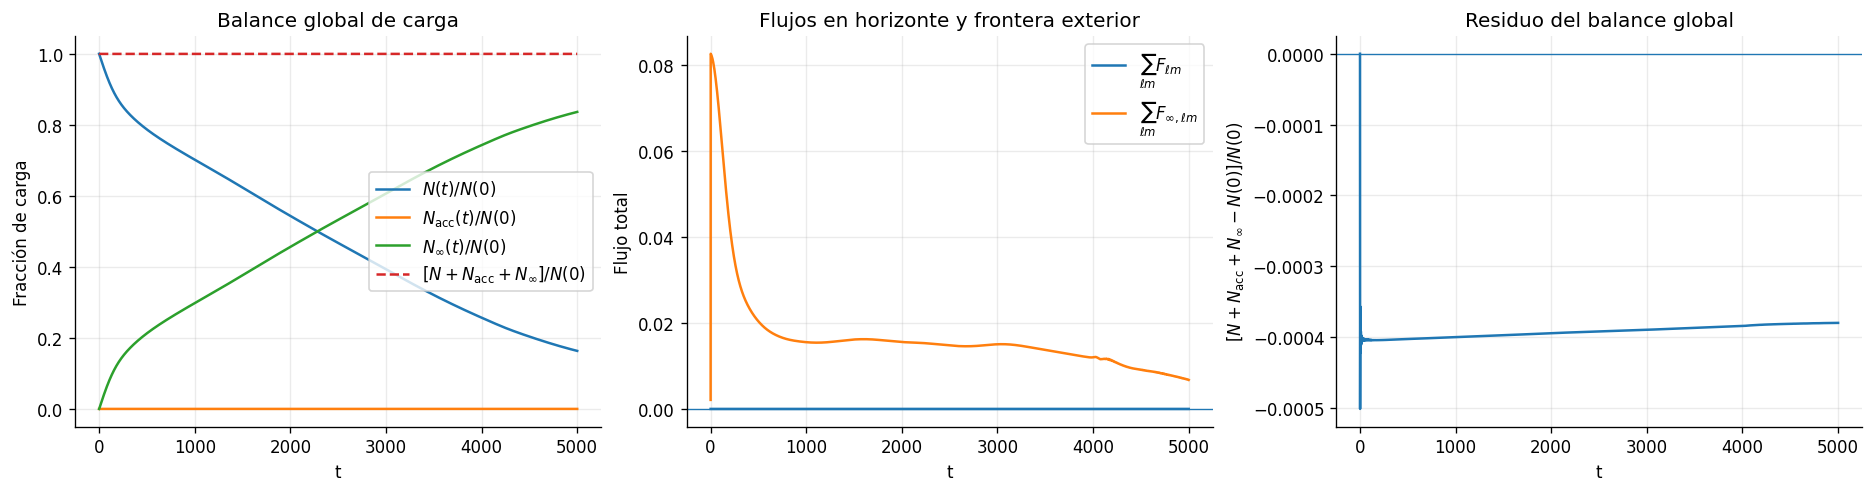

N(0)              = 1.000000000000e+02
N(t_final)        = 1.633720761469e+01
N_acc(t_final)    = 1.128983310526e-04
N_inf(t_final)    = 8.362466360455e+01
Residuo final     = -3.801588242295e-02


In [113]:
# ============================================================
# Balance global de carga
# ============================================================

with h5py.File(H5_PATH, "r") as h5:
    t_diag = h5["diagnostics/t"][:]

    total_N = summed_modal_series(h5["diagnostics/N"])
    total_F = summed_modal_series(h5["diagnostics/F"])

    total_Finf = FINF_SIGN * summed_modal_series(
        get_finf_dataset(h5)
    )

N0_global = total_N[0]

Nacc_global = cumulative_trapezoid_1d(t_diag, total_F)
Ninf_global = cumulative_trapezoid_1d(t_diag, total_Finf)

N_balance_global = (
    total_N
    + Nacc_global
    + Ninf_global
)

balance_residual_global = N_balance_global - N0_global

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.5, 4.0),
    constrained_layout=True,
)

ax = axes[0]

ax.plot(
    t_diag,
    total_N / N0_global,
    label=r"$N(t)/N(0)$",
)

ax.plot(
    t_diag,
    Nacc_global / N0_global,
    label=r"$N_{\rm acc}(t)/N(0)$",
)

ax.plot(
    t_diag,
    Ninf_global / N0_global,
    label=r"$N_{\infty}(t)/N(0)$",
)

ax.plot(
    t_diag,
    N_balance_global / N0_global,
    linestyle="--",
    label=r"$[N+N_{\rm acc}+N_{\infty}]/N(0)$",
)

ax.set_xlabel("t")
ax.set_ylabel("Fracción de carga")
ax.set_title("Balance global de carga")
ax.legend()


ax = axes[1]

ax.plot(
    t_diag,
    total_F,
    label=r"$\sum_{\ell m}F_{\ell m}$",
)

ax.plot(
    t_diag,
    total_Finf,
    label=r"$\sum_{\ell m}F_{\infty,\ell m}$",
)

ax.axhline(0.0, linewidth=0.8)

ax.set_xlabel("t")
ax.set_ylabel("Flujo total")
ax.set_title("Flujos en horizonte y frontera exterior")
ax.legend()


ax = axes[2]

ax.plot(
    t_diag,
    balance_residual_global / N0_global,
)

ax.axhline(0.0, linewidth=0.8)

ax.set_xlabel("t")
ax.set_ylabel(
    r"$[N+N_{\rm acc}+N_{\infty}-N(0)]/N(0)$"
)

ax.set_title("Residuo del balance global")

plt.show()

print(f"N(0)              = {N0_global:.12e}")
print(f"N(t_final)        = {total_N[-1]:.12e}")
print(f"N_acc(t_final)    = {Nacc_global[-1]:.12e}")
print(f"N_inf(t_final)    = {Ninf_global[-1]:.12e}")
print(
    "Residuo final     = "
    f"{balance_residual_global[-1]:.12e}"
)

/tmp/ipykernel_7552/1066844409.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  result[j0:j1] = np.trapz(values, x=t, axis=0)


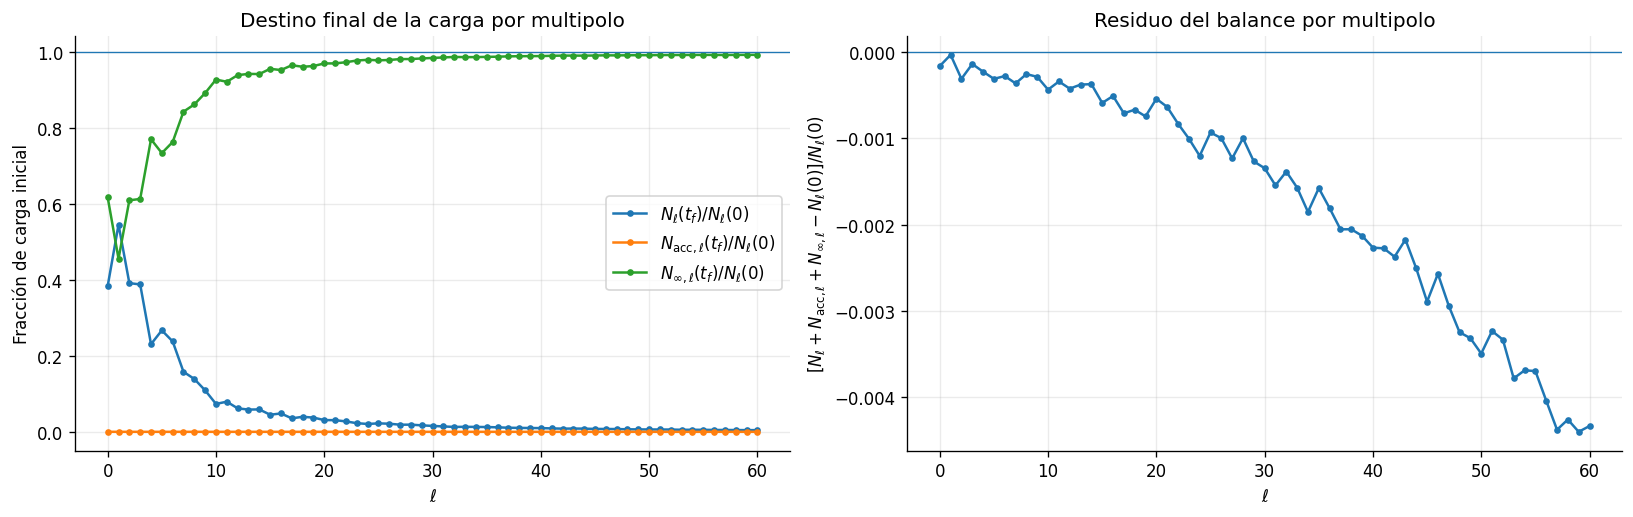

In [114]:
# ============================================================
# Balance de carga agrupado por multipolo ell
# ============================================================

with h5py.File(H5_PATH, "r") as h5:
    ell = h5["modes/ell"][:]
    N0 = h5["diagnostics/N"][0, :]
    Nf = h5["diagnostics/N"][-1, :]

    Nacc_lm = final_time_integral_per_mode(
        h5["diagnostics/F"],
        t_diag,
    )

    Ninf_lm = FINF_SIGN * final_time_integral_per_mode(
        get_finf_dataset(h5),
        t_diag,
    )

ell_values, N0_ell = sum_by_ell(N0, ell)
_, Nf_ell = sum_by_ell(Nf, ell)
_, Nacc_ell = sum_by_ell(Nacc_lm, ell)
_, Ninf_ell = sum_by_ell(Ninf_lm, ell)

balance_ell = Nf_ell + Nacc_ell + Ninf_ell - N0_ell

remaining_fraction = np.divide(
    Nf_ell,
    N0_ell,
    out=np.full_like(Nf_ell, np.nan),
    where=np.abs(N0_ell) > np.finfo(float).tiny,
)

accreted_fraction = np.divide(
    Nacc_ell,
    N0_ell,
    out=np.full_like(Nacc_ell, np.nan),
    where=np.abs(N0_ell) > np.finfo(float).tiny,
)

escaped_fraction = np.divide(
    Ninf_ell,
    N0_ell,
    out=np.full_like(Ninf_ell, np.nan),
    where=np.abs(N0_ell) > np.finfo(float).tiny,
)

balance_fraction = np.divide(
    balance_ell,
    N0_ell,
    out=np.full_like(balance_ell, np.nan),
    where=np.abs(N0_ell) > np.finfo(float).tiny,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 4.2),
    constrained_layout=True,
)

ax = axes[0]

ax.plot(
    ell_values,
    remaining_fraction,
    marker=".",
    label=r"$N_\ell(t_f)/N_\ell(0)$",
)

ax.plot(
    ell_values,
    accreted_fraction,
    marker=".",
    label=r"$N_{{\rm acc},\ell}(t_f)/N_\ell(0)$",
)

ax.plot(
    ell_values,
    escaped_fraction,
    marker=".",
    label=r"$N_{\infty,\ell}(t_f)/N_\ell(0)$",
)

ax.axhline(1.0, linewidth=0.8)

ax.set_xlabel(r"$\ell$")
ax.set_ylabel("Fracción de carga inicial")
ax.set_title("Destino final de la carga por multipolo")
ax.legend()


ax = axes[1]

ax.plot(
    ell_values,
    balance_fraction,
    marker=".",
)

ax.axhline(0.0, linewidth=0.8)

ax.set_xlabel(r"$\ell$")
ax.set_ylabel(
    r"$[N_\ell+N_{{\rm acc},\ell}+N_{\infty,\ell}-N_\ell(0)]/N_\ell(0)$"
)

ax.set_title("Residuo del balance por multipolo")

plt.show()

## Diagnóstico modal

La primera figura muestra la fracción de carga final de cada modo. Las siguientes dos condensan los diagnósticos sumando sobre $m$ para cada $\ell$.

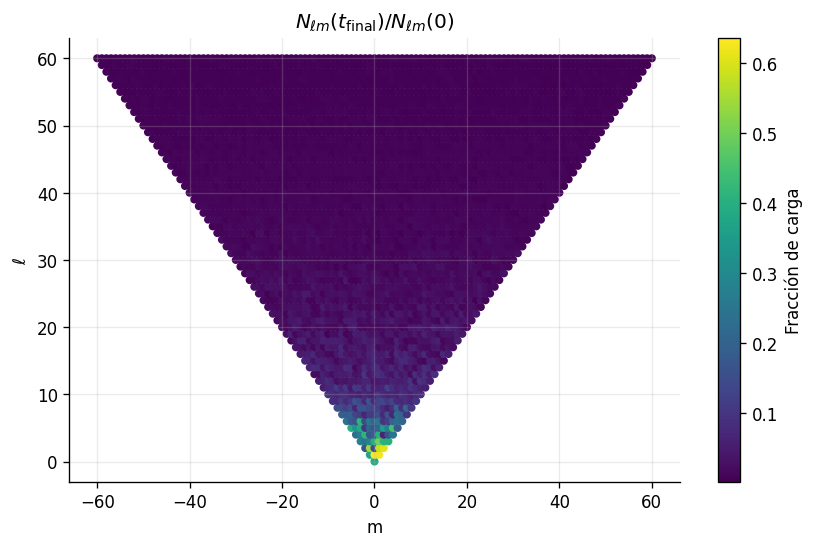

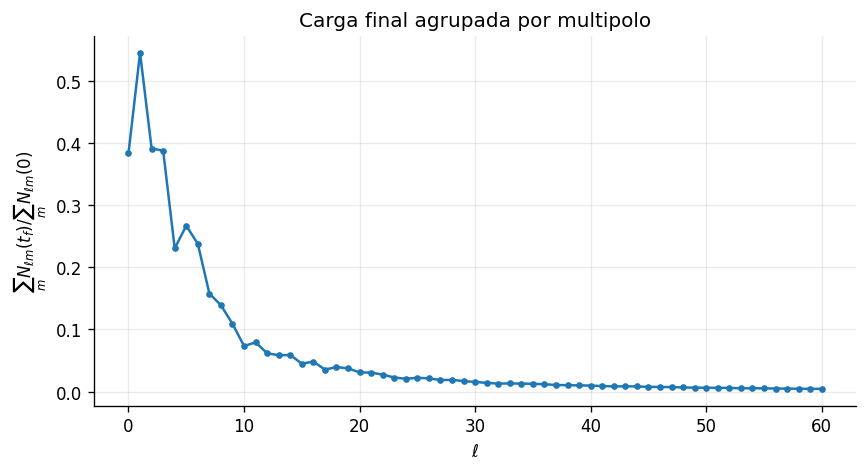

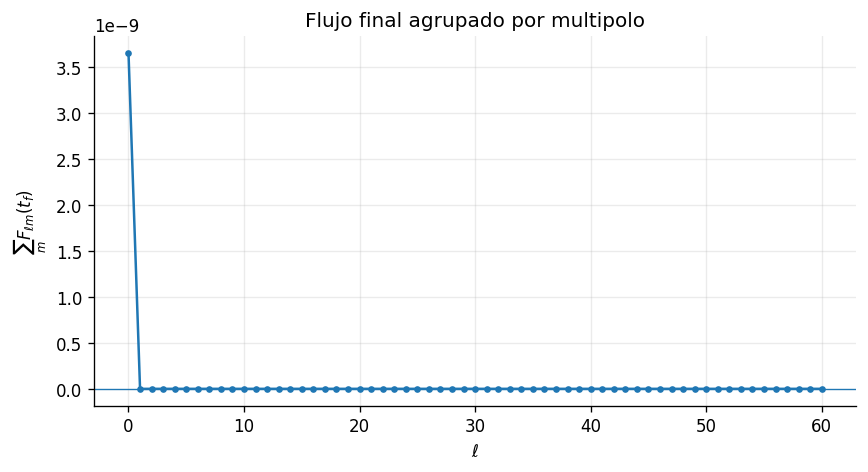

In [115]:
with h5py.File(H5_PATH, "r") as h5:
    ell = h5["modes/ell"][:]
    mm = h5["modes/mm"][:]
    N0 = h5["diagnostics/N"][0, :]
    Nf = h5["diagnostics/N"][-1, :]
    Ff = h5["diagnostics/F"][-1, :]

fraction = np.full(N0.shape, np.nan, dtype=float)
valid = np.abs(N0) > np.finfo(float).tiny
fraction[valid] = Nf[valid] / N0[valid]

fig, ax = plt.subplots(figsize=(8.2, 4.8))
artist = ax.scatter(mm, ell, c=fraction, s=15)
ax.set_xlabel("m")
ax.set_ylabel(r"$\ell$")
ax.set_title(r"$N_{\ell m}(t_{\rm final}) / N_{\ell m}(0)$")
fig.colorbar(artist, ax=ax, label="Fracción de carga")
plt.show()

ell_values, N0_ell = sum_by_ell(N0, ell)
_, Nf_ell = sum_by_ell(Nf, ell)
ratio_ell = np.divide(Nf_ell, N0_ell, out=np.full_like(Nf_ell, np.nan), where=np.abs(N0_ell) > 0.0)

fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.plot(ell_values, ratio_ell, marker=".")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\sum_m N_{\ell m}(t_f) / \sum_m N_{\ell m}(0)$")
ax.set_title("Carga final agrupada por multipolo")
plt.show()

ell_values, Ff_ell = sum_by_ell(Ff, ell)
fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.plot(ell_values, Ff_ell, marker=".")
ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\sum_m F_{\ell m}(t_f)$")
ax.set_title("Flujo final agrupado por multipolo")
plt.show()

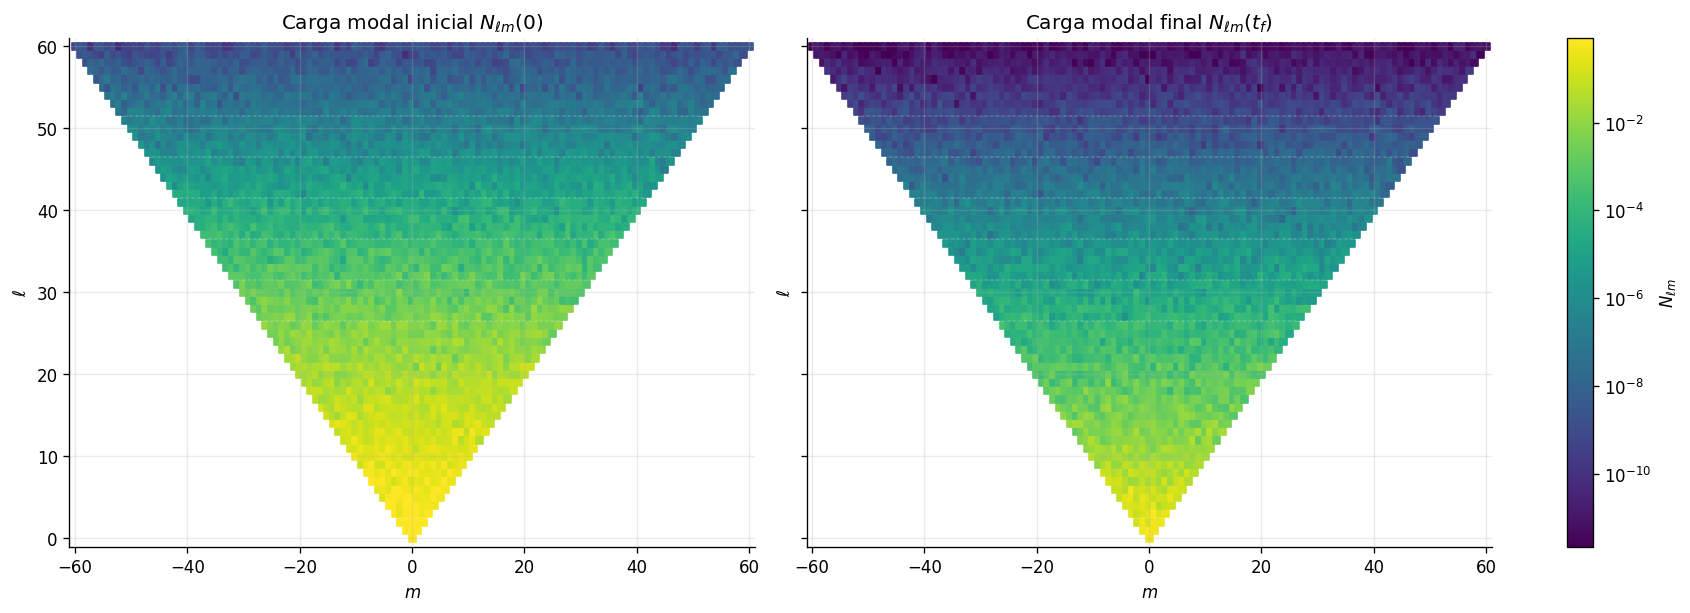

Carga inicial total = 1.000000000000e+02
Carga final total   = 1.633720761469e+01


In [116]:
# ============================================================
# Distribución triangular de carga modal:
# estado inicial y estado final
# ============================================================

with h5py.File(H5_PATH, "r") as h5:
    ell = h5["modes/ell"][:]
    mm = h5["modes/mm"][:]

    N_initial = h5["diagnostics/N"][0, :]
    N_final = h5["diagnostics/N"][-1, :]

ell_max_data = int(np.max(ell))

norm_charge = shared_charge_norm(
    N_initial,
    N_final,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14.0, 5.0),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

for ax, values, title in zip(
    axes,
    [N_initial, N_final],
    [
        r"Carga modal inicial $N_{\ell m}(0)$",
        r"Carga modal final $N_{\ell m}(t_f)$",
    ],
):
    artist = ax.scatter(
        mm,
        ell,
        c=values,
        s=18,
        marker="s",
        norm=norm_charge,
    )

    setup_triangle_axis(ax, ell_max_data)
    ax.set_title(title)

fig.colorbar(
    artist,
    ax=axes,
    label=r"$N_{\ell m}$",
)

plt.show()

print(f"Carga inicial total = {np.sum(N_initial):.12e}")
print(f"Carga final total   = {np.sum(N_final):.12e}")

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7552/2786514351.py:33: SyntaxWarning: invalid escape sequence '\m'
  label="Fracción de carga que salió por $r_{\max}$",


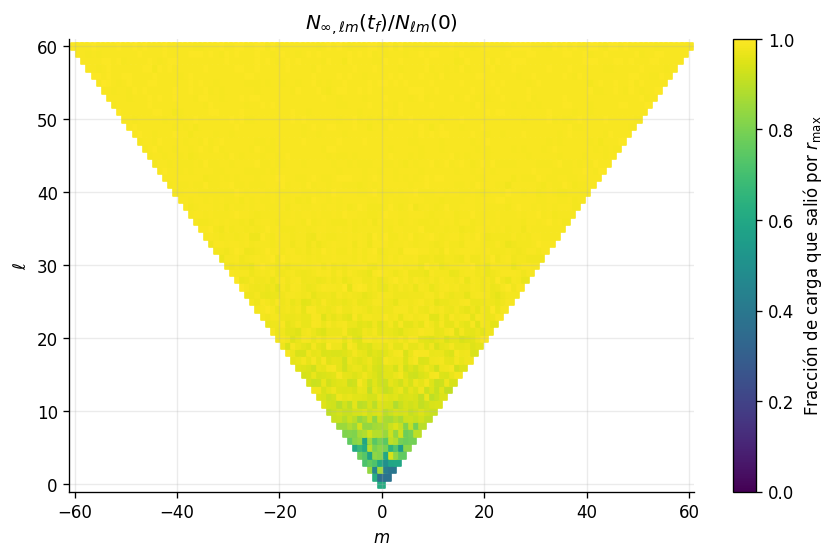

In [117]:
# ============================================================
# Carga acumulada que salió por r = rmax
# ============================================================

escaped_fraction_lm = np.divide(
    Ninf_lm,
    N0,
    out=np.full_like(Ninf_lm, np.nan),
    where=np.abs(N0) > np.finfo(float).tiny,
)

fig, ax = plt.subplots(figsize=(8.4, 4.9))

artist = ax.scatter(
    mm,
    ell,
    c=escaped_fraction_lm,
    s=18,
    marker="s",
    vmin=0.0,
    vmax=1.0,
)

setup_triangle_axis(ax, ell_max_data)

ax.set_title(
    r"$N_{\infty,\ell m}(t_f)/N_{\ell m}(0)$"
)

fig.colorbar(
    artist,
    ax=ax,
    label="Fracción de carga que salió por $r_{\max}$",
)

plt.show()

## Perfiles radiales

Selecciona un modo mediante `SELECTED_MODE = (ell, m)`. Se grafican tres tiempos representativos: inicial, intermedio y final.

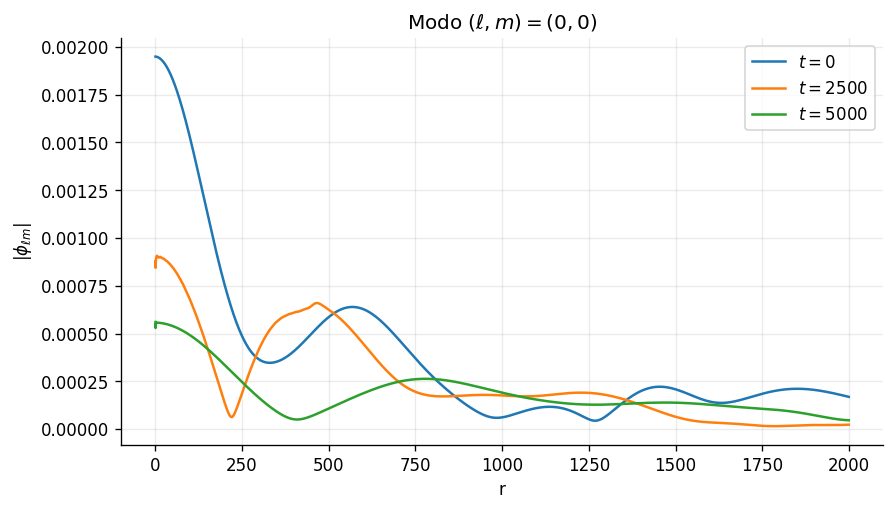

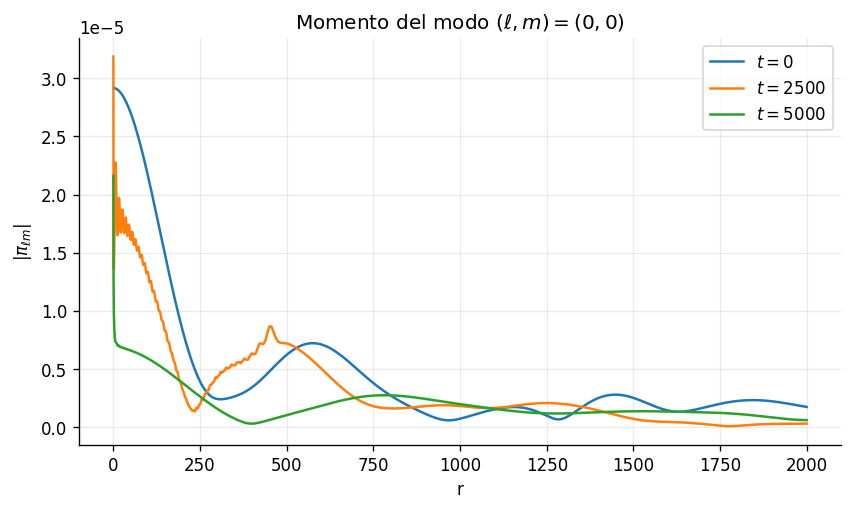

In [118]:
with h5py.File(H5_PATH, "r") as h5:
    r = h5["grid/r"][:]
    ell = h5["modes/ell"][:]
    mm = h5["modes/mm"][:]
    t_field = h5["fields/t"][:]

    imode = selected_mode_index(ell, mm, SELECTED_MODE)
    ell_sel, m_sel = int(ell[imode]), int(mm[imode])
    rs = radial_slice(r, R_DISPLAY_MAX)
    r_plot = r[rs]
    it_values = sorted(set([0, len(t_field) // 2, len(t_field) - 1]))

    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    for it in it_values:
        field = complex_modal_field(h5, "phi", it, imode, rs)
        ax.plot(r_plot, np.abs(field), label=fr"$t={t_field[it]:.6g}$")
    ax.set_xlabel("r")
    ax.set_ylabel(r"$|\phi_{\ell m}|$")
    ax.set_title(fr"Modo $(\ell,m)=({ell_sel},{m_sel})$")
    #ax.set_xlim(980,1020)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    for it in it_values:
        field = complex_modal_field(h5, "pi", it, imode, rs)
        ax.plot(r_plot, np.abs(field), label=fr"$t={t_field[it]:.6g}$")
    ax.set_xlabel("r")
    ax.set_ylabel(r"$|\pi_{\ell m}|$")
    ax.set_title(fr"Momento del modo $(\ell,m)=({ell_sel},{m_sel})$")
    #ax.set_xlim(980,1020)
    ax.legend()
    plt.show()

## Reconstrucción en el plano $xy$

El plano se guarda en la representación nativa $(r,\varphi)$ y aquí se dibuja directamente en coordenadas cartesianas. La celda se salta de forma limpia cuando el grupo `/planes/xy` no existe.

/tmp/ipykernel_7552/527011557.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  image = ax.pcolormesh(x, y, values, shading="auto", norm=color_norm(values, PART_TO_PLOT))


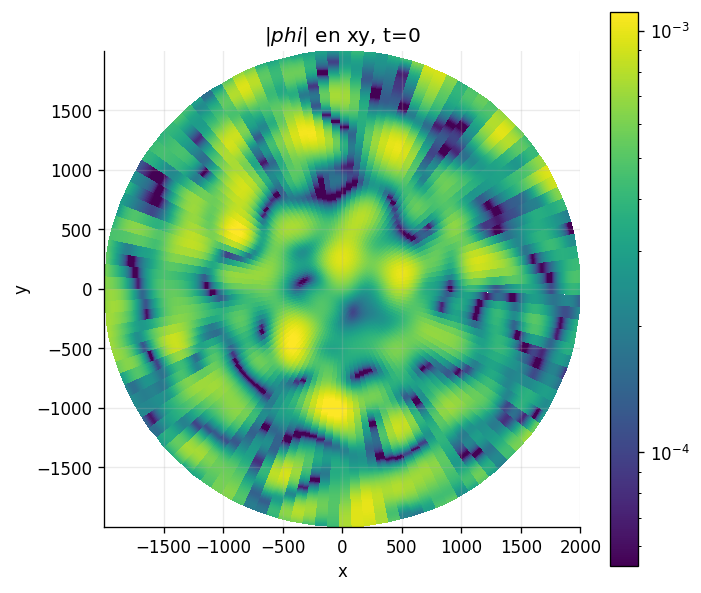

In [119]:
with h5py.File(H5_PATH, "r") as h5:
    if "planes" not in h5 or "xy" not in h5["planes"]:
        print("No hay salida /planes/xy en este archivo.")
    else:
        plane_t = h5["planes/t"][:]
        it = closest_time_index(plane_t, PLANE_TIME_REQUEST)
        plane = plane_complex_xy(h5, FIELD_TO_PLOT, it)
        r_plane = h5["planes/xy/r"][:]
        varphi = h5["planes/xy/varphi"][:]
        plane = orient_angular_radial(plane, varphi.size, r_plane.size)

        values = component(plane, PART_TO_PLOT)
        x = np.cos(varphi)[:, None] * r_plane[None, :]
        y = np.sin(varphi)[:, None] * r_plane[None, :]

        fig, ax = plt.subplots(figsize=(6.4, 6.0))
        image = ax.pcolormesh(x, y, values, shading="auto", norm=color_norm(values, PART_TO_PLOT))
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"{component_label(FIELD_TO_PLOT, PART_TO_PLOT)} en xy, t={plane_t[it]:.6g}")
        fig.colorbar(image, ax=ax)
        plt.show()

## Reconstrucción en el plano $xz$

El semiplano `plus` usa $\varphi=0$ y el semiplano `minus` usa $\varphi=\pi$. Se dibujan juntos para recuperar el corte completo. Esta celda requiere guardar las partes real e imaginaria de ambos semiplanos.

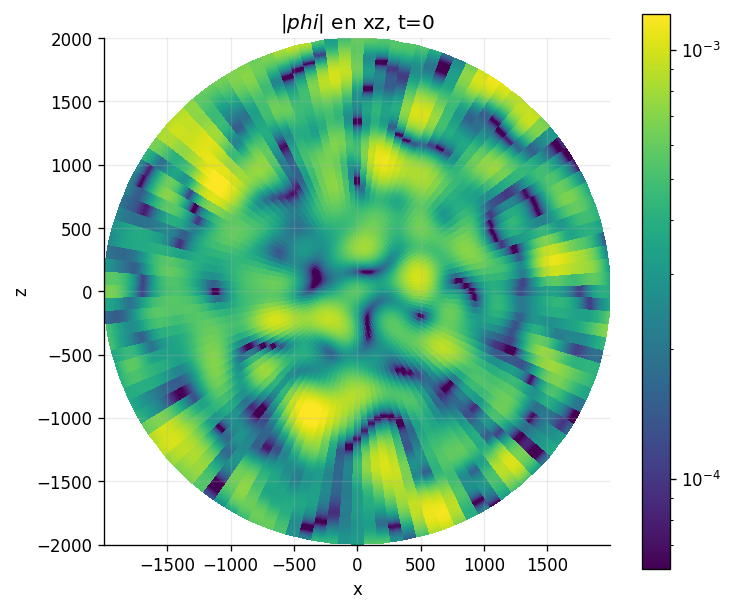

In [120]:
with h5py.File(H5_PATH, "r") as h5:
    if "planes" not in h5 or "xz" not in h5["planes"]:
        print("No hay salida /planes/xz en este archivo.")
    else:
        try:
            plane_t = h5["planes/t"][:]
            it = closest_time_index(plane_t, PLANE_TIME_REQUEST)
            r_plane = h5["planes/xz/r"][:]
            theta = h5["planes/xz/theta"][:]

            plus = orient_angular_radial(
                plane_complex_xz(h5, FIELD_TO_PLOT, it, "plus"), theta.size, r_plane.size
            )
            minus = orient_angular_radial(
                plane_complex_xz(h5, FIELD_TO_PLOT, it, "minus"), theta.size, r_plane.size
            )

            values_plus = component(plus, PART_TO_PLOT)
            values_minus = component(minus, PART_TO_PLOT)
            all_values = np.concatenate([values_plus.ravel(), values_minus.ravel()])

            z = np.cos(theta)[:, None] * r_plane[None, :]
            x_plus = np.sin(theta)[:, None] * r_plane[None, :]
            x_minus = -x_plus
            norm = color_norm(all_values, PART_TO_PLOT)

            fig, ax = plt.subplots(figsize=(6.8, 6.0))
            image = ax.pcolormesh(x_plus, z, values_plus, shading="auto", norm=norm)
            ax.pcolormesh(x_minus, z, values_minus, shading="auto", norm=norm)
            ax.set_aspect("equal")
            ax.set_xlabel("x")
            ax.set_ylabel("z")
            ax.set_title(f"{component_label(FIELD_TO_PLOT, PART_TO_PLOT)} en xz, t={plane_t[it]:.6g}")
            fig.colorbar(image, ax=ax)
            plt.show()
        except KeyError as exc:
            print(f"La salida xz está incompleta para {FIELD_TO_PLOT}: {exc}")

## Consulta rápida de un snapshot

Esta celda permite inspeccionar valores y tiempos disponibles antes de añadir una figura específica.

In [121]:
with h5py.File(H5_PATH, "r") as h5:
    print("Tiempos 0D:", h5["diagnostics/t"][:])
    print("Tiempos 1D:", h5["fields/t"][:])

    if "planes" in h5:
        print("Tiempos de planos:", h5["planes/t"][:])
        for plane_name in h5["planes"]:
            if isinstance(h5["planes"][plane_name], h5py.Group):
                print(f"/planes/{plane_name}: {list(h5['planes'][plane_name].keys())}")

Tiempos 0D: [0.000e+00 1.000e+00 2.000e+00 ... 4.998e+03 4.999e+03 5.000e+03]
Tiempos 1D: [   0.  500. 1000. 1500. 2000. 2500. 3000. 3500. 4000. 4500. 5000.]
Tiempos de planos: [   0.   50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.
  600.  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150.
 1200. 1250. 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650. 1700. 1750.
 1800. 1850. 1900. 1950. 2000. 2050. 2100. 2150. 2200. 2250. 2300. 2350.
 2400. 2450. 2500. 2550. 2600. 2650. 2700. 2750. 2800. 2850. 2900. 2950.
 3000. 3050. 3100. 3150. 3200. 3250. 3300. 3350. 3400. 3450. 3500. 3550.
 3600. 3650. 3700. 3750. 3800. 3850. 3900. 3950. 4000. 4050. 4100. 4150.
 4200. 4250. 4300. 4350. 4400. 4450. 4500. 4550. 4600. 4650. 4700. 4750.
 4800. 4850. 4900. 4950. 5000.]
/planes/xy: ['phi_im', 'phi_re', 'pi_im', 'pi_re', 'r', 'varphi']
/planes/xz: ['phi_im_minus', 'phi_im_plus', 'phi_re_minus', 'phi_re_plus', 'pi_im_minus', 'pi_im_plus', 'pi_re_minus', 'pi_re_plus', 'r', 'th

## Película sincronizada de los planos $xy$ y $xz$

La película usa los planos fusionados y mantiene una escala de color fija en toda la secuencia.

In [122]:
import matplotlib
from matplotlib.animation import FFMpegWriter
from matplotlib.patches import Circle
from IPython.display import Video, display

# ============================================================
# Configuración
# ============================================================
MOVIE_FIELD = "phi"          # "phi" o "pi"
MOVIE_PART  = "abs"          # "abs", "real" o "imag"

MOVIE_FPS    = 12
MOVIE_DPI    = 140
FRAME_STRIDE = 1
MOVIE_R_MAX  = None          # None -> usa todo el radio disponible

NORM_SAMPLE_PER_PLANE = 100_000

MOVIE_CMAP = "viridis" if MOVIE_PART == "abs" else "RdBu_r"

DRAW_HORIZON  = True
HORIZON_RADIUS = 1.0

MOVIE_PATH = RUN_DIR / f"{RUN_DIR.name}_{MOVIE_FIELD}_{MOVIE_PART}_xy_xz.mp4"

if not FFMpegWriter.isAvailable():
    raise RuntimeError(
        "Matplotlib no encuentra ffmpeg. Instálalo con:\n"
        "sudo apt install ffmpeg"
    )

print(f"Salida: {MOVIE_PATH}")

Salida: SL_all_p005/SL_all_p005_phi_abs_xy_xz.mp4


In [123]:
def movie_radial_slice(r, rmax=None):
    if rmax is None:
        return slice(None)

    return slice(0, max(1, np.searchsorted(r, rmax, side="right")))


def radial_edges(r):
    r = np.asarray(r)

    if r.size < 2:
        raise ValueError("Se requieren al menos dos puntos radiales.")

    edges = np.empty(r.size + 1, dtype=r.dtype)
    edges[0] = r[0]
    edges[1:-1] = 0.5 * (r[:-1] + r[1:])
    edges[-1] = r[-1] + 0.5 * (r[-1] - r[-2])

    return edges


def periodic_angle_edges(angle):
    angle = np.asarray(angle)

    if angle.size < 2:
        raise ValueError("Se requieren al menos dos puntos angulares.")

    dangle = np.median(np.diff(angle))

    return angle[0] - 0.5 * dangle + dangle * np.arange(angle.size + 1)


def polar_angle_edges(theta):
    theta = np.asarray(theta)

    if theta.size < 2:
        raise ValueError("Se requieren al menos dos puntos angulares.")

    edges = np.empty(theta.size + 1, dtype=theta.dtype)
    edges[0] = theta[0]
    edges[1:-1] = 0.5 * (theta[:-1] + theta[1:])
    edges[-1] = theta[-1]

    return edges


def sample_plane_values(values, sample_size, rng):
    values = np.asarray(values).ravel()
    values = values[np.isfinite(values)]

    if values.size <= sample_size:
        return values

    index = rng.choice(values.size, size=sample_size, replace=False)

    return values[index]


def movie_color_norm(h5, frame_indices, field, part, radial_index):
    rng = np.random.default_rng(20260622)
    samples = []

    xy = h5["planes/xy"]
    xz = h5["planes/xz"]

    r_xy = xy["r"][:]
    varphi = xy["varphi"][:]

    r_xz = xz["r"][:]
    theta = xz["theta"][:]

    for it in frame_indices:

        z_xy = orient_angular_radial(
            plane_complex_xy(h5, field, it),
            varphi.size,
            r_xy.size,
        )[:, radial_index]

        samples.append(
            sample_plane_values(
                component(z_xy, part),
                NORM_SAMPLE_PER_PLANE,
                rng,
            )
        )

        for side in ("plus", "minus"):

            z_xz = orient_angular_radial(
                plane_complex_xz(h5, field, it, side),
                theta.size,
                r_xz.size,
            )[:, radial_index]

            samples.append(
                sample_plane_values(
                    component(z_xz, part),
                    NORM_SAMPLE_PER_PLANE,
                    rng,
                )
            )

    values = np.concatenate([sample for sample in samples if sample.size > 0])

    if values.size == 0:
        raise RuntimeError("No hay valores finitos para construir la escala de color.")

    if part == "abs":

        positive = values[values > 0.0]

        if positive.size == 0:
            raise RuntimeError("El campo es nulo en todos los snapshots seleccionados.")

        vmin = max(np.percentile(positive, 1.0), np.finfo(np.float64).tiny)
        vmax = np.percentile(positive, 99.8)

        if vmax <= vmin:
            vmax = 10.0 * vmin

        return LogNorm(vmin=vmin, vmax=vmax)

    vmax = np.percentile(np.abs(values), 99.8)

    if vmax <= 0.0:
        vmax = 1.0

    return SymLogNorm(
        linthresh=max(vmax * 1.0e-4, np.finfo(np.float64).tiny),
        vmin=-vmax,
        vmax=vmax,
    )


def plot_xy_frame(ax, h5, it, field, part, radial_index, norm, cmap):
    group = h5["planes/xy"]

    r = group["r"][:][radial_index]
    varphi = group["varphi"][:]

    z = orient_angular_radial(
        plane_complex_xy(h5, field, it),
        varphi.size,
        group["r"].size,
    )[:, radial_index]

    values = component(z, part)

    r_edges = radial_edges(r)
    varphi_edges = periodic_angle_edges(varphi)

    x = np.cos(varphi_edges)[:, None] * r_edges[None, :]
    y = np.sin(varphi_edges)[:, None] * r_edges[None, :]

    image = ax.pcolormesh(
        x,
        y,
        values,
        shading="flat",
        cmap=cmap,
        norm=norm,
    )

    rmax = np.max(r_edges)

    ax.set_xlim(-rmax, rmax)
    ax.set_ylim(-rmax, rmax)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if DRAW_HORIZON:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                HORIZON_RADIUS,
                fill=False,
                ec="white",
                lw=0.8,
            )
        )

    return image


def plot_xz_frame(ax, h5, it, field, part, radial_index, norm, cmap):
    group = h5["planes/xz"]

    r = group["r"][:][radial_index]
    theta = group["theta"][:]

    plus = orient_angular_radial(
        plane_complex_xz(h5, field, it, "plus"),
        theta.size,
        group["r"].size,
    )[:, radial_index]

    minus = orient_angular_radial(
        plane_complex_xz(h5, field, it, "minus"),
        theta.size,
        group["r"].size,
    )[:, radial_index]

    values_plus = component(plus, part)
    values_minus = component(minus, part)

    r_edges = radial_edges(r)
    theta_edges = polar_angle_edges(theta)

    z = np.cos(theta_edges)[:, None] * r_edges[None, :]
    x_plus = np.sin(theta_edges)[:, None] * r_edges[None, :]
    x_minus = -x_plus

    image = ax.pcolormesh(
        x_plus,
        z,
        values_plus,
        shading="flat",
        cmap=cmap,
        norm=norm,
    )

    ax.pcolormesh(
        x_minus,
        z,
        values_minus,
        shading="flat",
        cmap=cmap,
        norm=norm,
    )

    rmax = np.max(r_edges)

    ax.set_xlim(-rmax, rmax)
    ax.set_ylim(-rmax, rmax)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("z")

    if DRAW_HORIZON:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                HORIZON_RADIUS,
                fill=False,
                ec="white",
                lw=0.8,
            )
        )

    return image

In [124]:
with h5py.File(H5_PATH, "r") as h5:

    if "planes" not in h5 or "xy" not in h5["planes"] or "xz" not in h5["planes"]:
        raise KeyError("El archivo fusionado debe contener /planes/xy y /planes/xz.")

    plane_t = h5["planes/t"][:]

    frame_indices = np.arange(
        0,
        plane_t.size,
        FRAME_STRIDE,
        dtype=int,
    )

    if frame_indices.size == 0:
        raise RuntimeError("No hay snapshots de planos para generar la película.")

    r_xy = h5["planes/xy/r"][:]
    r_xz = h5["planes/xz/r"][:]

    if r_xy.shape != r_xz.shape or not np.allclose(
        r_xy,
        r_xz,
        rtol=0.0,
        atol=1.0e-13,
    ):
        raise ValueError("Las mallas radiales de xy y xz no coinciden.")

    radial_index = movie_radial_slice(r_xy, MOVIE_R_MAX)

    norm = movie_color_norm(
        h5,
        frame_indices,
        MOVIE_FIELD,
        MOVIE_PART,
        radial_index,
    )

    fig = plt.figure(figsize=(12.4, 6.0), constrained_layout=True)

    grid = fig.add_gridspec(
        1,
        3,
        width_ratios=(1.0, 1.0, 0.045),
    )

    ax_xy = fig.add_subplot(grid[0, 0])
    ax_xz = fig.add_subplot(grid[0, 1])
    cax = fig.add_subplot(grid[0, 2])

    writer = FFMpegWriter(
        fps=MOVIE_FPS,
        codec="libx264",
        bitrate=-1,
        extra_args=["-pix_fmt", "yuv420p"],
    )

    with writer.saving(fig, str(MOVIE_PATH), MOVIE_DPI):

        for iframe, it in enumerate(frame_indices, start=1):

            ax_xy.clear()
            ax_xz.clear()
            cax.clear()

            image = plot_xy_frame(
                ax_xy,
                h5,
                it,
                MOVIE_FIELD,
                MOVIE_PART,
                radial_index,
                norm,
                MOVIE_CMAP,
            )

            plot_xz_frame(
                ax_xz,
                h5,
                it,
                MOVIE_FIELD,
                MOVIE_PART,
                radial_index,
                norm,
                MOVIE_CMAP,
            )

            ax_xy.set_title(rf"$xy$, $t={plane_t[it]:.6g}$")
            ax_xz.set_title(rf"$xz$, $t={plane_t[it]:.6g}$")

            fig.colorbar(
                image,
                cax=cax,
                label=component_label(MOVIE_FIELD, MOVIE_PART),
            )

            writer.grab_frame()

            if iframe == 1 or iframe % 10 == 0 or iframe == frame_indices.size:
                print(
                    f"Frame {iframe:4d}/{frame_indices.size}: "
                    f"t={plane_t[it]:.6g}"
                )

    plt.close(fig)

print(f"Película creada: {MOVIE_PATH}")
display(Video(str(MOVIE_PATH), embed=False))

Frame    1/101: t=0
Frame   10/101: t=450
Frame   20/101: t=950
Frame   30/101: t=1450
Frame   40/101: t=1950
Frame   50/101: t=2450
Frame   60/101: t=2950
Frame   70/101: t=3450
Frame   80/101: t=3950
Frame   90/101: t=4450
Frame  100/101: t=4950
Frame  101/101: t=5000
Película creada: SL_all_p005/SL_all_p005_phi_abs_xy_xz.mp4


In [126]:
from pathlib import Path
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Archivo fusionado
# ============================================================

H5_FILE = Path("SL_all_p005/SL_all_p005.h5")
SPECTRUM_GROUP = "spectrum"


# ============================================================
# Lectura
# ============================================================

def as_time_mode(array, nt, nmodes, label):
    """
    Garantiza que P tenga forma P[it, n].
    """
    array = np.asarray(array, dtype=float).squeeze()

    if array.shape == (nt, nmodes):
        return array

    if array.shape == (nmodes, nt):
        return array.T

    raise ValueError(
        f"{label}: forma inesperada {array.shape}. "
        f"Esperaba ({nt}, {nmodes}) o ({nmodes}, {nt})."
    )


def load_spectrum(filename):
    """
    Lee el espectro completo contenido en un único archivo HDF5.

    Retorna:
        spec["t"]              -> tiempos
        spec["ell"][ell]["k"]  -> k_{ell n}
        spec["ell"][ell]["lambda"]
        spec["ell"][ell]["P"]  -> P_phi[time, n]
    """
    filename = Path(filename)

    with h5py.File(filename, "r") as h5:

        root = h5[SPECTRUM_GROUP]

        # Ajusta esta parte si tu dataset temporal tiene otro nombre.
        for candidate in ("t", "time", "t_spectrum"):
            if candidate in root:
                t = np.asarray(root[candidate], dtype=float).squeeze()
                break
        else:
            raise KeyError(
                "No encontré el dataset de tiempo. "
                "Busqué: t, time, t_spectrum."
            )

        ell_data = {}

        for name, group in root.items():

            if not isinstance(group, h5py.Group):
                continue

            if re.fullmatch(r"ell_\d+", name) is None:
                continue

            if "P_phi_local" not in group:
                continue

            ell = int(name.split("_")[1])

            k = np.asarray(group["k"], dtype=float).squeeze()
            lam = np.asarray(group["lambda"], dtype=float).squeeze()

            P = as_time_mode(
                group["P_phi_local"][...],
                nt=len(t),
                nmodes=len(k),
                label=f"{name}/P_phi_local"
            )

            ell_data[ell] = {
                "k": k,
                "lambda": lam,
                "P": P,
            }

    return {
        "t": t,
        "ell": ell_data,
    }


spec = load_spectrum(H5_FILE)

t = spec["t"]
ells_available = sorted(spec["ell"])

print(f"Archivo:                 {H5_FILE}")
print(f"Snapshots espectrales:   {len(t)}")
print(f"Rango temporal:          [{t[0]:.6g}, {t[-1]:.6g}]")
print(f"Multipolos disponibles:  {ells_available[0]} ... {ells_available[-1]}")
print(f"Número de multipolos:    {len(ells_available)}")

for ell in ells_available[:3]:
    k = spec["ell"][ell]["k"]
    lam = spec["ell"][ell]["lambda"]

    err = np.max(
        np.abs(lam - k**2) / np.maximum(np.abs(lam), 1.0e-14)
    )

    print(
        f"ell = {ell:4d} | "
        f"Nmodes = {len(k):5d} | "
        f"max rel. error lambda-k^2 = {err:.3e}"
    )

Archivo:                 SL_all_p005/SL_all_p005.h5
Snapshots espectrales:   11
Rango temporal:          [0, 5000]
Multipolos disponibles:  0 ... 60
Número de multipolos:    61
ell =    0 | Nmodes =  5200 | max rel. error lambda-k^2 = 0.000e+00
ell =    1 | Nmodes =  5200 | max rel. error lambda-k^2 = 0.000e+00
ell =    2 | Nmodes =  5200 | max rel. error lambda-k^2 = 0.000e+00


Eigenmodos totales:          317200
Bandas construidas:          80
Estados por banda:           3965 -- 3965
Suma P_phi(t = 0):           7.75289411e+03
Suma P_phi(t = 5000): 1.41726132e+03


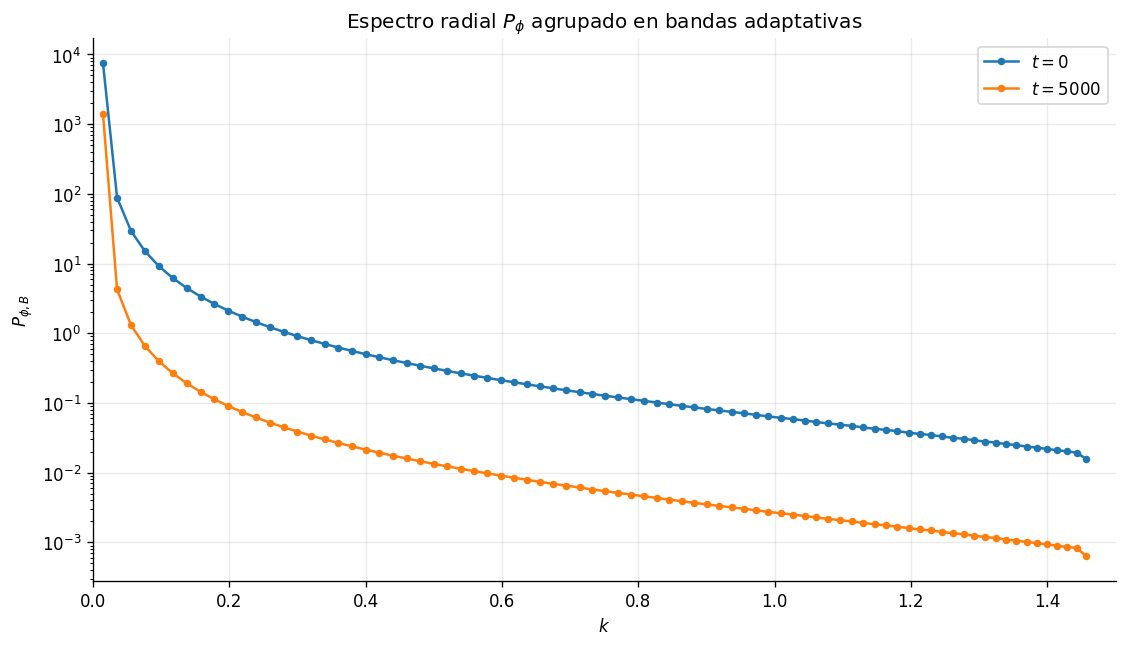

In [135]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Reúne todos los estados (ell,n) en un orden fijo
# ============================================================

def collect_phi_states(spec, it, ells=None):

    if ells is None:
        ells = sorted(spec["ell"])

    k_all = []
    P_all = []

    for ell in ells:

        k = np.asarray(spec["ell"][ell]["k"], dtype=float)
        P = np.asarray(spec["ell"][ell]["P"][it], dtype=float)

        valid = (
            np.isfinite(k)
            & np.isfinite(P)
            & (k >= 0.0)
        )

        k_all.append(k[valid])
        P_all.append(np.maximum(P[valid], 0.0))

    return np.concatenate(k_all), np.concatenate(P_all)


# ============================================================
# Bandas adaptativas: mismo número de eigenmodos por banda
# ============================================================

def build_mode_bands(spec, n_bands=80, ells=None):
    """
    Construye bandas a partir del orden global de los eigenmodos.

    Cada banda contiene aproximadamente el mismo número de estados
    discretos (ell,n), independientemente de la densidad local en k.
    """
    k_all, _ = collect_phi_states(spec, it=0, ells=ells)

    order = np.argsort(k_all, kind="stable")
    k_sorted = k_all[order]

    n_modes = len(k_sorted)
    n_bands = min(int(n_bands), n_modes)

    band_id = np.floor(
        n_bands * np.arange(n_modes) / n_modes
    ).astype(int)

    band_id = np.minimum(band_id, n_bands - 1)

    counts = np.bincount(
        band_id,
        minlength=n_bands
    )

    k_center = np.zeros(n_bands)

    for j in range(n_bands):
        k_center[j] = np.median(k_sorted[band_id == j])

    return {
        "order": order,
        "band_id": band_id,
        "k_center": k_center,
        "counts": counts,
        "n_bands": n_bands,
        "n_modes": n_modes,
        "k_sorted": k_sorted,
    }


# ============================================================
# Potencia P_phi contenida en cada banda
# ============================================================

def binned_phi_power(spec, it, bands, ells=None):
    """
    P_band[j] = suma de P_{phi,ell,n} de todos los eigenmodos
    pertenecientes a la banda j.

    No divide entre Delta k.
    """
    k_all, P_all = collect_phi_states(spec, it=it, ells=ells)

    if len(k_all) != bands["n_modes"]:
        raise RuntimeError(
            "El número de eigenmodos cambió respecto a la construcción "
            "de las bandas."
        )

    P_sorted = P_all[bands["order"]]

    P_band = np.bincount(
        bands["band_id"],
        weights=P_sorted,
        minlength=bands["n_bands"]
    )

    return {
        "k": bands["k_center"],
        "P": P_band,
        "counts": bands["counts"],
        "P_total": P_band.sum(),
    }


# ============================================================
# Gráfica simple de P_phi
# ============================================================

ells_total = sorted(spec["ell"])

it0 = 0
itf = len(spec["t"]) - 1

N_BANDS = 80

bands = build_mode_bands(
    spec,
    n_bands=N_BANDS,
    ells=ells_total
)

B0 = binned_phi_power(
    spec,
    it=it0,
    bands=bands,
    ells=ells_total
)

Bf = binned_phi_power(
    spec,
    it=itf,
    bands=bands,
    ells=ells_total
)

print(f"Eigenmodos totales:          {bands['n_modes']}")
print(f"Bandas construidas:          {bands['n_bands']}")
print(f"Estados por banda:           {bands['counts'].min()} -- {bands['counts'].max()}")
print(f"Suma P_phi(t = 0):           {B0['P_total']:.8e}")
print(f"Suma P_phi(t = {spec['t'][itf]:.6g}): {Bf['P_total']:.8e}")


fig, ax = plt.subplots(figsize=(9.5, 5.5))

mask0 = B0["P"] > 0.0
maskf = Bf["P"] > 0.0

ax.plot(
    B0["k"][mask0],
    B0["P"][mask0],
    marker="o",
    ms=3.5,
    lw=1.5,
    label=rf"$t={spec['t'][it0]:.6g}$"
)

ax.plot(
    Bf["k"][maskf],
    Bf["P"][maskf],
    marker="o",
    ms=3.5,
    lw=1.5,
    label=rf"$t={spec['t'][itf]:.6g}$"
)

ax.set_yscale("log")

ax.set_xlim(
    0.0,
    1.03 * max(B0["k"].max(), Bf["k"].max())
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$P_{\phi,B}$")
ax.set_title(r"Espectro radial $P_\phi$ agrupado en bandas adaptativas")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

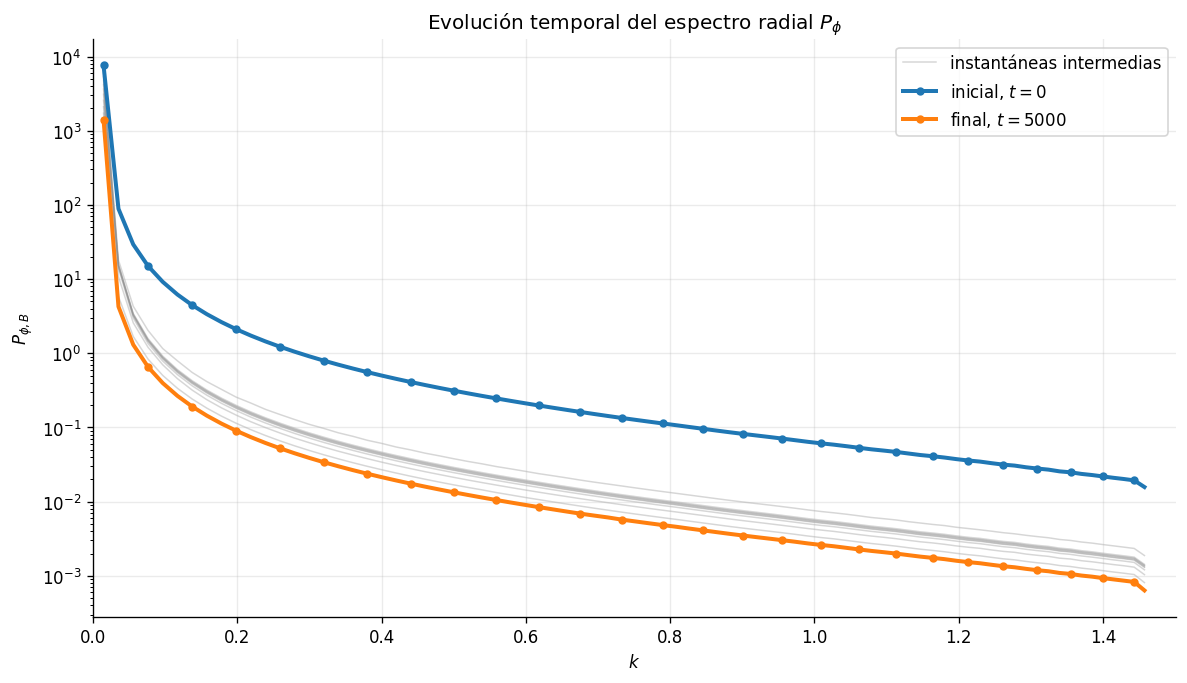

In [137]:
# ============================================================
# Evolución temporal del espectro radial binned
# ============================================================

ells_total = sorted(spec["ell"])

# Usa todas las instantáneas guardadas.
# Cambia a 2, 3, ... si más adelante tienes demasiadas.
SNAPSHOT_STRIDE = 1

snapshot_ids = np.arange(0, len(spec["t"]), SNAPSHOT_STRIDE)

if snapshot_ids[-1] != len(spec["t"]) - 1:
    snapshot_ids = np.append(snapshot_ids, len(spec["t"]) - 1)

# Cada fila contiene P_{phi,B}(t) para las mismas bandas adaptativas.
P_time = np.empty((len(snapshot_ids), bands["n_bands"]))

for j, it in enumerate(snapshot_ids):
    B = binned_phi_power(
        spec,
        it=it,
        bands=bands,
        ells=ells_total
    )
    P_time[j] = B["P"]

k_band = B["k"]

# ============================================================
# Gráfica
# ============================================================

fig, ax = plt.subplots(figsize=(10.0, 5.8))

# Instantáneas intermedias: todas con el mismo color.
INTERMEDIATE_COLOR = "0.55"   # gris medio

for j, it in enumerate(snapshot_ids[1:-1], start=1):

    y = np.where(P_time[j] > 0.0, P_time[j], np.nan)

    label = "instantáneas intermedias" if j == 1 else "_nolegend_"

    ax.plot(
        k_band,
        y,
        color=INTERMEDIATE_COLOR,
        lw=0.9,
        alpha=0.35,
        label=label,
        zorder=1
    )

# Estado inicial.
y_initial = np.where(P_time[0] > 0.0, P_time[0], np.nan)

ax.plot(
    k_band,
    y_initial,
    marker="o",
    ms=4.0,
    markevery=max(1, len(k_band) // 24),
    lw=2.4,
    label=rf"inicial, $t={spec['t'][snapshot_ids[0]]:.6g}$",
    zorder=3
)

# Estado final.
y_final = np.where(P_time[-1] > 0.0, P_time[-1], np.nan)

ax.plot(
    k_band,
    y_final,
    marker="o",
    ms=4.0,
    markevery=max(1, len(k_band) // 24),
    lw=2.4,
    label=rf"final, $t={spec['t'][snapshot_ids[-1]]:.6g}$",
    zorder=4
)

ax.set_yscale("log")

ax.set_xlim(
    0.0,
    1.03 * np.max(k_band)
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$P_{\phi,B}$")
ax.set_title(r"Evolución temporal del espectro radial $P_\phi$")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()